# Phase 0: Pipeline Initialization, Data Sourcing & Architectural Setup

### 🎯 Overview & Action Plan
Before executing any analytical or computational task, establishing a rigid, warning-free environment and securing data alignment is paramount. This initial phase sets up our scientific computing ecosystem.

Our architectural plan for this phase consists of:
1. **Workspace Anchoring:** Mounting the remote Google Drive repository to ensure persistent data streams.
2. **Environment Stabilization:** Silencing core runtime warnings (`FutureWarning` / `UserWarning`) to guarantee clean, professional reporting.
3. **Multi-Algorithmic Dependency Loading:** Importing specialized modules for mathematical computing (`numpy`, `pandas`), scientific visualization (`seaborn`, `matplotlib`), and latent space decomposition (`sklearn`).
4. **Feature Space Harmonization:** Segregating the clinical ground-truth target from the independent variable matrices.

In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 0: SETUP & INITIALIZATION
# =======================================================================

# --- 0.1 REMOTE WORKSPACE MOUNTING ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --- 0.2 ENVIRONMENT STABILIZATION ---
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# --- 0.3 MATHEMATICAL, GRAPHICAL & ML DEPENDENCIES ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")

# --- 0.4 DATA SOURCING ---
path = '/content/drive/MyDrive/heart.csv'
df = pd.read_csv(path)

# --- 0.5 DATASET AUDIT ---
print("======================================================================")
print("🔬 WORKSPACE RUNTIME METRIC AUDIT")
print("======================================================================")
print(f"📐 Raw Clinical DataFrame Shape : {df.shape}")
print(f"📋 Dataset Columns              : {df.columns.tolist()}")
print("======================================================================")


Mounted at /content/drive
🔬 WORKSPACE RUNTIME METRIC AUDIT
📐 Raw Clinical DataFrame Shape : (1025, 14)
📋 Dataset Columns              : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


# Phase 1: Data Quality Audit & Exploratory Expression Profiling

### 🎯 Objective
Before injecting data into dimensionality reduction algorithms, a rigorous quality audit is mandatory. This phase ensures data integrity, checks for missing attributes that could compromise matrix operations, and examines the initial global correlation architecture of our clinical features.

Our pipeline implements:
1. **Matrix Completeness Check:** Explicit verification of null entry vectors.
2. **Global Correlation Profiling:** Mapping the unmodified feature space to identify initial collinearity patterns before geometric standard scaling.

🔬 INITIAL DATASET COMPLETENESS AUDIT
📐 Dataset Matrix Dimensions (Samples x Features): (1025, 14)
✅ Matrix Integrity: 100% complete. Zero missing entries detected.


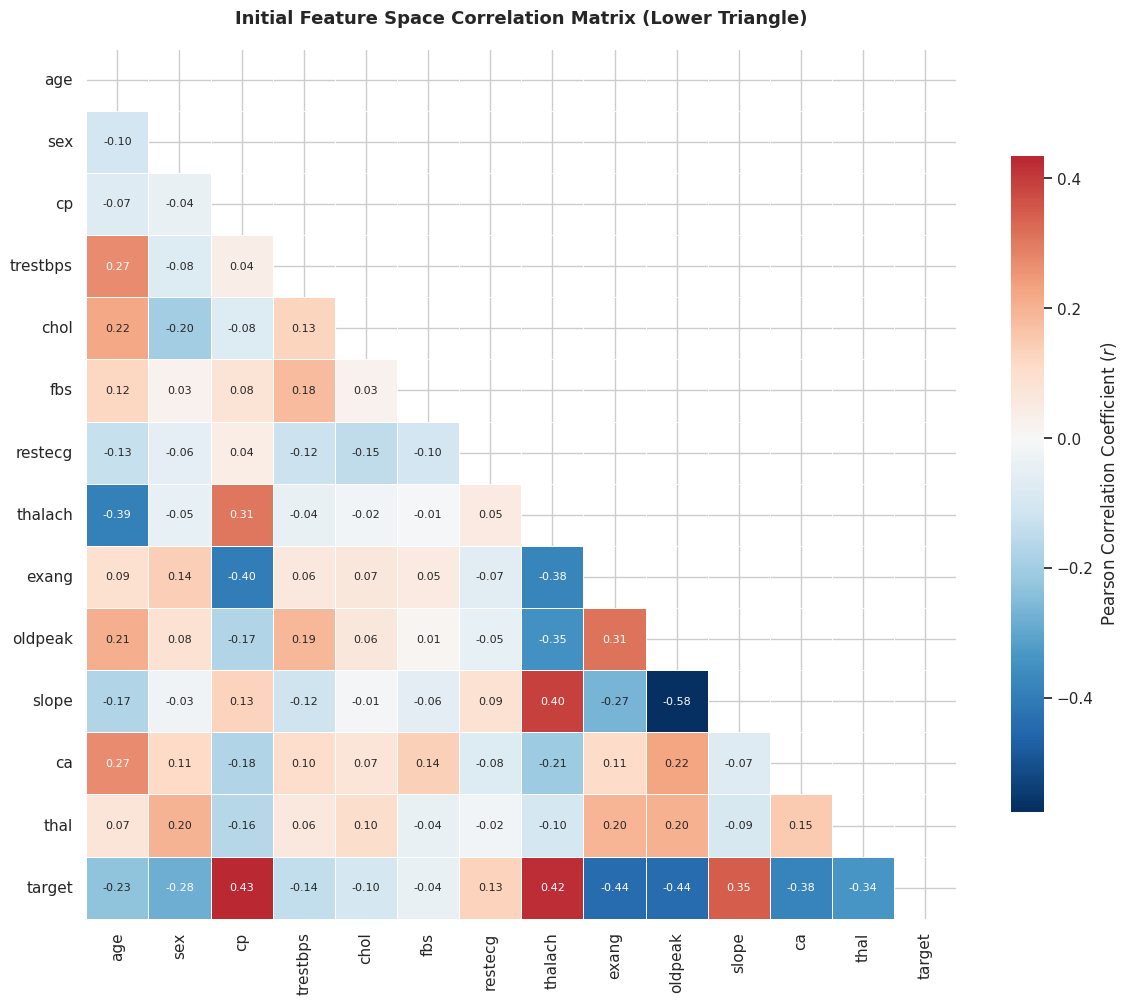

In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 1: DATA AUDIT & CORRELATION PROFILING
# =======================================================================

# --- 1 MATRIX COMPLETENESS & INTEGRITY AUDIT ---
print("======================================================================")
print("🔬 INITIAL DATASET COMPLETENESS AUDIT")
print("======================================================================")
print(f"📐 Dataset Matrix Dimensions (Samples x Features): {df.shape}")

missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("✅ Matrix Integrity: 100% complete. Zero missing entries detected.")
else:
    print("⚠️ Missing values detected within the following vectors:")
    print(missing_values[missing_values > 0])
print("======================================================================")

# --- 1.2 GLOBAL FEATURE CORRELATION ARCHITECTURE ---
# Computing the Pearson product-moment correlation coefficients
corr_matrix = df.corr()

# Generating a strict upper triangle mask to eliminate geometric redundancy
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Setting up the professional plotting canvas
fig, ax = plt.subplots(figsize=(12, 10))

# Customizing the heatmap using a diverging, scientifically sound colormap (RdBu_r)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .75, "label": "Pearson Correlation Coefficient ($r$)"},
    annot_kws={"size": 8, "fontweight": "medium"},
    ax=ax
)

# Refined title and layout adjustments (preventing label truncation)
ax.set_title("Initial Feature Space Correlation Matrix (Lower Triangle)", fontsize=13, fontweight='bold', pad=18)
plt.tight_layout()
plt.show()

### 🔍 Duplicate Record Audit

Before proceeding with downstream analyses, we verify whether the dataset contains repeated observations. Duplicate rows may artificially increase the weight of specific patient profiles, distort descriptive statistics, and bias both clustering and supervised models. This audit reports the total number of records, the number of exact duplicates, and the effective number of unique patient profiles.


In [ ]:
# =======================================================================
# PHASE 1.1: DUPLICATE RECORD AUDIT
# =======================================================================

duplicate_count = df.duplicated().sum()
unique_count = len(df.drop_duplicates())

print("=" * 65)
print("DUPLICATE RECORD AUDIT")
print("=" * 65)
print(f"Total rows:      {len(df)}")
print(f"Duplicate rows:  {duplicate_count}")
print(f"Unique patients: {unique_count}")
print("=" * 65)

DUPLICATE RECORD AUDIT
Total rows:      1025
Duplicate rows:  723
Unique patients: 302


### 🧹 Duplicate Removal and Dataset Consolidation

After identifying repeated observations, exact duplicates are removed to preserve one instance of each patient profile. The index is then reset to maintain a clean and continuous data structure. A final verification confirms the resulting dataset dimensions and ensures that no duplicate rows remain before preprocessing and modelling.


In [ ]:
# =======================================================================
# PHASE 1.2: DUPLICATE REMOVAL
# =======================================================================

df = df.drop_duplicates().reset_index(drop=True)

print("=" * 65)
print("DATASET AFTER DUPLICATE REMOVAL")
print("=" * 65)
print(f"Final dataset shape: {df.shape}")
print(f"Remaining duplicate rows: {df.duplicated().sum()}")
print("=" * 65)

DATASET AFTER DUPLICATE REMOVAL
Final dataset shape: (302, 14)
Remaining duplicate rows: 0


# Phase 2: FULL CROSS-CORRELATION MATRIX

### 🔍 Full-Scale Cross-Correlation Mapping

To evaluate the complete interplay across the entire continuous and discrete feature space, we compute an unmasked, full-scale Pearson cross-correlation profile. While a masked lower-triangle representation isolates directional dependencies, mapping the symmetrical structure provides an extensive global layout of the dataset. This architectural view allows for a quick diagnostic of potential collinear variables that could impact our linear decompositions.

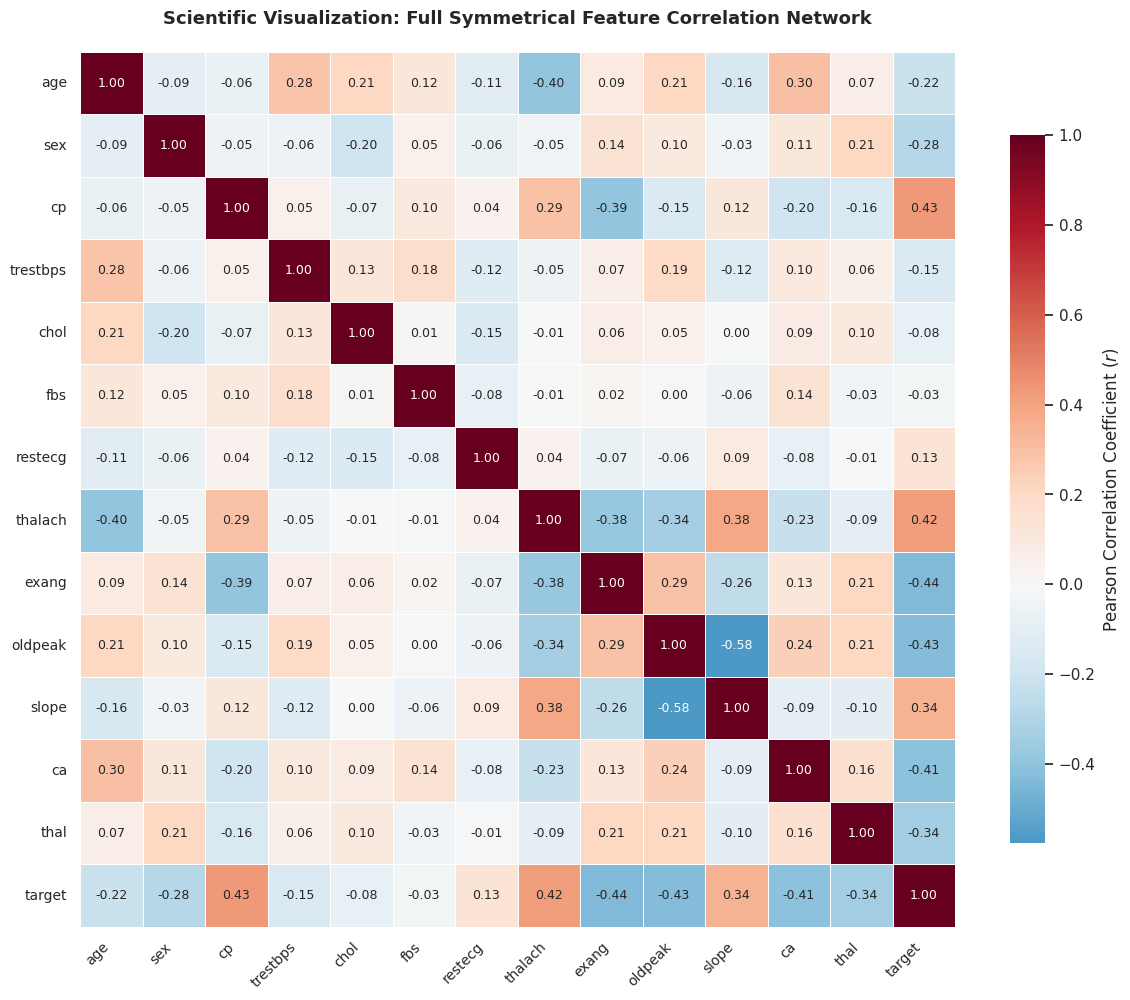

In [ ]:
# =======================================================================
# PHASE 2: FULL CROSS-CORRELATION MATRIX
# =======================================================================

# --- 2.1 COMPUTING SYMMETRIC PRODUCT-MOMENT COEFFICIENTS ---
# Calculating Pearson matrices to observe raw directional association weights
corr = df.corr()

# --- 2.2 CANVAS PARAMETRIZATION & HEATMAP GENERATION ---
plt.figure(figsize=(12, 10))

# Applying the high-contrast diverging colormap (RdBu_r) centered perfectly at zero
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8, "label": "Pearson Correlation Coefficient ($r$)"},
    annot_kws={"size": 9, "fontweight": "medium"}
)

# --- 2.3 REFINING FORMATTING AND ROTATION STATES ---
plt.title("Scientific Visualization: Full Symmetrical Feature Correlation Network", fontsize=13, fontweight='bold', pad=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### 🔍 Distributional Audit & Outlier Screening

Before applying coordinate transformations or space alignment workflows, checking the distribution of continuous features is essential. This step uses a boxplot framework to screen key continuous parameters (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`). Since distance-based models and linear decompositions are highly sensitive to extreme values, this screening establishes the methodological necessity for standard scaling.

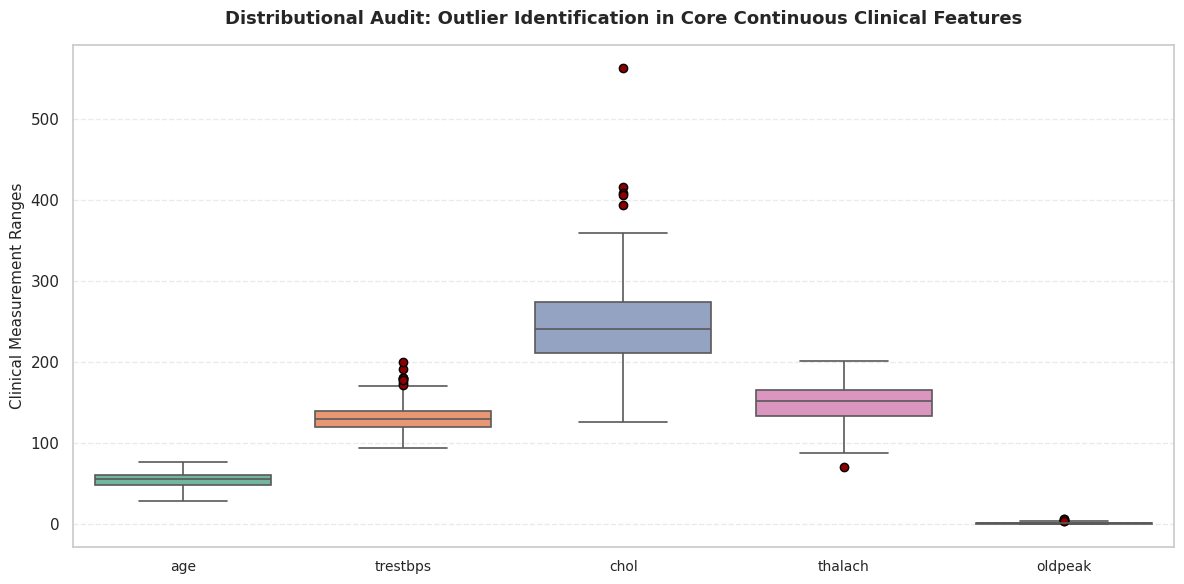

In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 2.1: PHYSIOLOGICAL OUTLIER AUDIT
# =======================================================================

# --- 1. DEFINING CONTINUOUS VARIABLES SUBSET ---
cols_to_check = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# --- 2. PLOTTING THE DISTRIBUTION MATRIX ---
plt.figure(figsize=(12, 6))

# Customizing boxplots with precise outlier markers and muted color maps
sns.boxplot(
    data=df[cols_to_check],
    palette="Set2",
    linewidth=1.2,
    fliersize=5,
    flierprops=dict(marker='o', markerfacecolor='darkred', markersize=6, markeredgecolor='black')
)

# --- 3. REFINING TITLES AND GRAPHICAL CANVAS ---
plt.title('Distributional Audit: Outlier Identification in Core Continuous Clinical Features', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Clinical Measurement Ranges', fontsize=11)
plt.xticks(fontsize=10, fontweight='medium')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Phase 3: Data Preprocessing, Feature Scaling & Geometric Alignment

### 🎯 Objective
Parametric mathematical decompositions (such as PCA) and centroid-based distance algorithms require variables to be on a uniform geometric scale. This section separates the independent clinical metrics from the ground-truth diagnosis labels and applies a standard Z-score transformation. This forces each parameter to possess a mean of 0 and a standard deviation of 1, ensuring isotropic variance across the entire space.

In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 3: FEATURE SCALING & SYSTEM VERIFICATION
# =======================================================================

# --- 3.1 MATRIX ISOLATION ---
# Separating independent clinical variables from the categorical target label
X = df.drop("target", axis=1)
y = df["target"]

# --- 3.2 GEOMETRIC STANDARD SCALING (Z-SCORE) ---
# Transforming features to center their distribution and balance mathematical weights
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3.3 METRIC INTEGRITY VERIFICATION ---
print("======================================================================")
print("🔬 PREPROCESSING OPERATIONAL METRIC VERIFICATION")
print("======================================================================")
print(f"📐 Processed Predictor Matrix Dimensions : {X_scaled.shape}")
print(f"µ Empirical Scaled Vector Mean        : {np.round(X_scaled.mean(), 2)} (Expected: ~0)")
print(f"σ Empirical Scaled Vector Std Dev     : {X_scaled.std()} (Expected: 1)")
print("======================================================================")
print("\nFirst 2 standardized rows matrix sample:")
print(np.round(X_scaled[:2], 3))
print("======================================================================")

🔬 PREPROCESSING OPERATIONAL METRIC VERIFICATION
📐 Processed Predictor Matrix Dimensions : (302, 13)
µ Empirical Scaled Vector Mean        : -0.0 (Expected: ~0)
σ Empirical Scaled Vector Std Dev     : 1.0 (Expected: 1)

First 2 standardized rows matrix sample:
[[-0.268  0.683 -0.935 -0.377 -0.668 -0.418  0.902  0.806 -0.698 -0.037
   0.98   1.275  1.12 ]
 [-0.157  0.683 -0.935  0.479 -0.842  2.39  -1.003  0.237  1.432  1.774
  -2.271 -0.715  1.12 ]]


# Phase 4: Exploratory Data Analysis & Primary Correlation Insights

### 🎯 Objective
Following the global linear space decomposition, we return to the raw clinical feature space to run an targeted, explicit correlation audit against our diagnostic endpoint (`target`). This step isolates and identifies the precise physiological features that share the highest linear variance with the presence or absence of cardiac disease, establishing our first direct clinical insights.

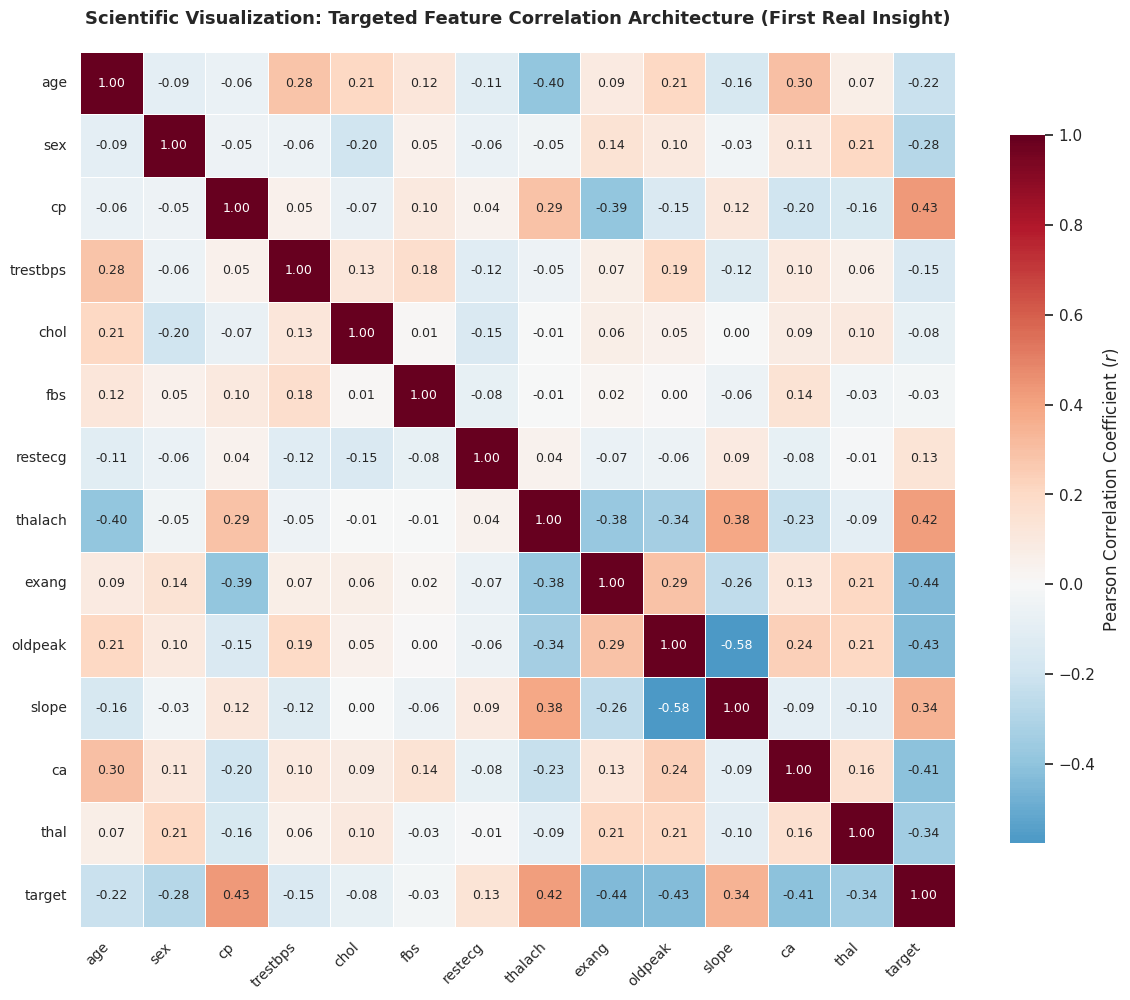

In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 4: PRIMARY CORRELATION INSIGHTS
# =======================================================================

# --- 4.1 CALCULATION OF THE FULL EMBEDDED CORRELATION MATRIX ---
# Re-computing Pearson product-moment coefficients across the current active dataframe
corr = df.corr()

# --- 4.2 CANVAS PRESET & REFINED HEATMAP DISPLAY ---
plt.figure(figsize=(12, 10))

# Applying the high-contrast professional diverging colormap (RdBu_r) centered perfectly at zero
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8, "label": "Pearson Correlation Coefficient ($r$)"},
    annot_kws={"size": 9, "fontweight": "medium"}
)

# --- 4.3 AXES SEMANTICS AND GRAPHICAL ADJUSTMENTS ---
plt.title("Scientific Visualization: Targeted Feature Correlation Architecture (First Real Insight)", fontsize=13, fontweight='bold', pad=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Phase 5: Latent Space Geometry & Dimensionality Reduction (PCA Biplot)

### 🎯 Objective
To compress the high-dimensional standardized feature space into an optimized 2D plane, we execute Principal Component Analysis (PCA). This linear mathematical decomposition allows us to project the multi-omic and clinical feature vectors alongside patient coordinates onto the primary orthogonal eigenvectors ($PC1$ and $PC2$). This step is critical to visualize data variance and determine how specific biomarkers dynamically drive patient classification.

### 📊 PCA Explained-Variance Profile

Before interpreting a two-dimensional PCA projection, it is necessary to quantify how much information is retained by each principal component. The scree plot displays the percentage of variance explained individually by every component, while the cumulative curve shows how progressively adding components reconstructs the original feature space. The 80% reference line provides an intuitive benchmark for assessing the dimensionality required to preserve most of the dataset variability.


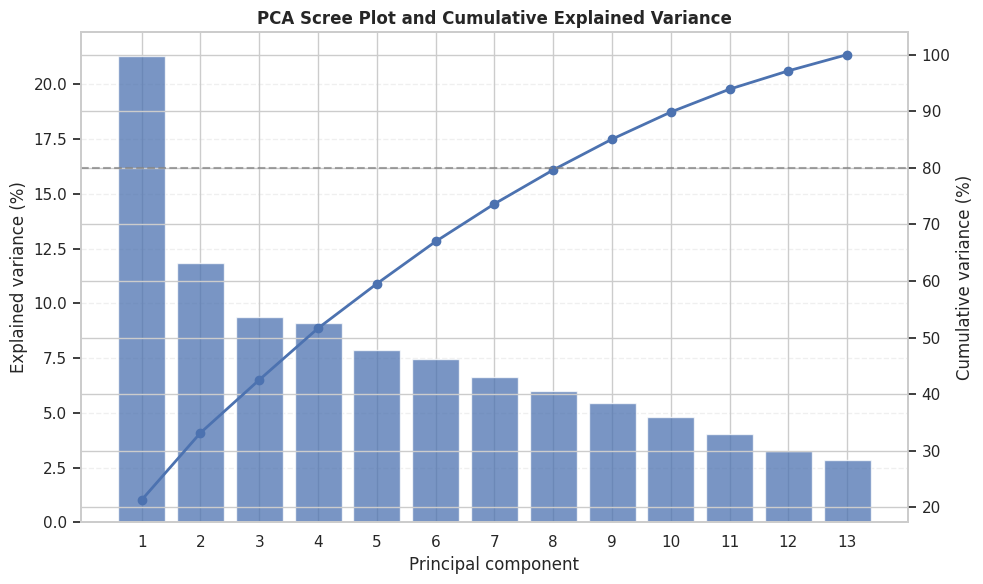

Variance explained by PC1: 21.31%
Variance explained by PC2: 11.86%
Variance explained by PC1 + PC2: 33.17%


In [ ]:
# =======================================================================
# PHASE 5: PCA EXPLAINED VARIANCE PROFILE
# =======================================================================

pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)
components = np.arange(1, len(explained) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(
    components,
    explained,
    alpha=0.75,
    label='Individual explained variance'
)

ax1.set_xlabel('Principal component')
ax1.set_ylabel('Explained variance (%)')
ax1.set_xticks(components)

ax2 = ax1.twinx()

ax2.plot(
    components,
    cumulative,
    marker='o',
    linewidth=2,
    label='Cumulative explained variance'
)

ax2.set_ylabel('Cumulative variance (%)')
ax2.axhline(80, linestyle='--', color='gray', alpha=0.7)

plt.title(
    'PCA Scree Plot and Cumulative Explained Variance',
    fontweight='bold'
)

ax1.grid(True, axis='y', linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Variance explained by PC1: {explained[0]:.2f}%")
print(f"Variance explained by PC2: {explained[1]:.2f}%")
print(f"Variance explained by PC1 + PC2: {cumulative[1]:.2f}%")

### 🧭 PCA Biplot: Patients and Feature Loadings

The biplot combines two complementary layers of information in the same latent space. Patient observations are projected onto the first two principal components and colored according to their true clinical status, while arrows represent feature loadings. The direction and length of each arrow indicate how strongly and in which direction the original clinical variables contribute to the principal components, helping connect the geometric patient distribution with its physiological drivers.


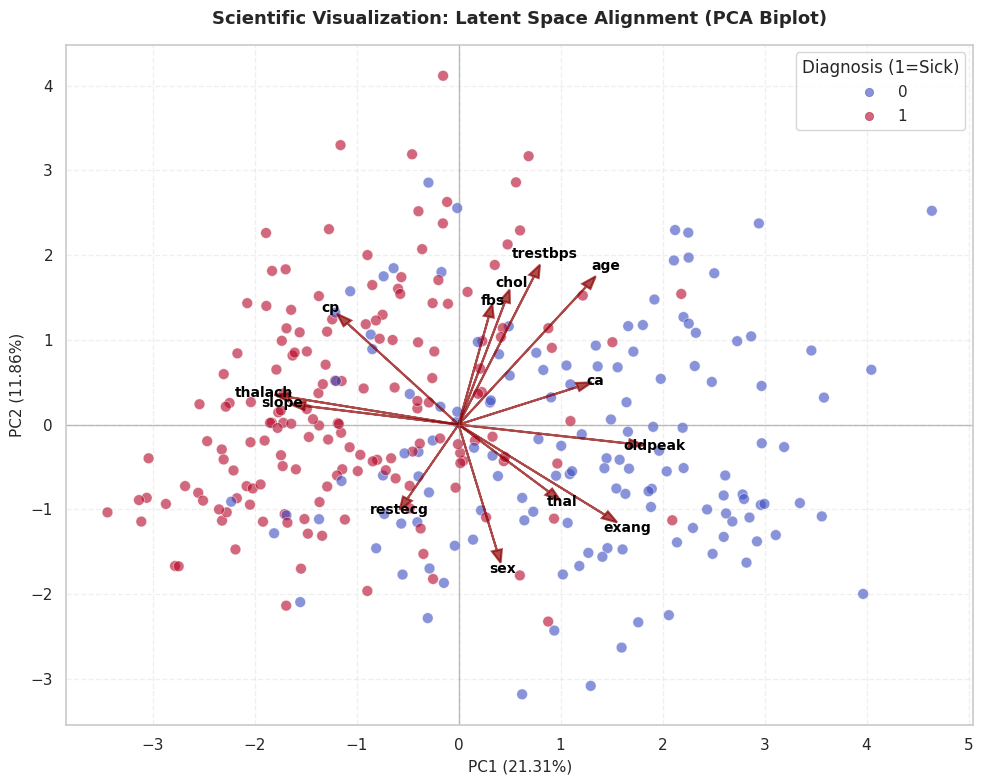

In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 5.1: LATENT SPACE PCA BI-PLOT
# =======================================================================

# --- 5.1 COMPUTING THE LINEAR ORTHOGONAL DECOMPOSITION ---
# Fitting the linear PCA transformer on the verified standardized matrix
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# --- 5.2 DEFINING THE ADVANCED COHORT BI-PLOT FUNCTION ---
def plot_pca_biplot(score, coeff, labels=None):
    plt.figure(figsize=(10, 8))

    # Projecting patient spatial coordinates, colored by true categorical target status
    scatter = plt.scatter(score[:,0], score[:,1], c=y, cmap='coolwarm', s=60, alpha=0.6, edgecolors='w', lw=0.5)

    # Projecting feature loading vectors (arrows) to define latent driving forces
    arrow_scale = 4.0
    for i in range(coeff.shape[0]):
        plt.arrow(0, 0, coeff[i,0]*arrow_scale, coeff[i,1]*arrow_scale, color='darkred', alpha=0.7, head_width=0.1, lw=1.5)
        if labels is not None:
            plt.text(coeff[i,0]*(arrow_scale + 0.6), coeff[i,1]*(arrow_scale + 0.6), labels[i],
                     color='black', ha='center', va='center', fontweight='bold', fontsize=10)

    # Extracting the exact mathematical variance ratios from the active transformer
    var_exp = np.round(pca.explained_variance_ratio_ * 100, 2)

    # Polishing axes semantics, scaling intervals, and structural grids
    plt.xlabel(f"PC1 ({var_exp[0]}%)", fontsize=11, fontweight='medium')
    plt.ylabel(f"PC2 ({var_exp[1]}%)", fontsize=11, fontweight='medium')
    plt.title("Scientific Visualization: Latent Space Alignment (PCA Biplot)", fontsize=13, fontweight='bold', pad=15)

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.axhline(0, color='grey', lw=1, alpha=0.5)
    plt.axvline(0, color='grey', lw=1, alpha=0.5)
    plt.legend(*scatter.legend_elements(), title="Diagnosis (1=Sick)", loc='upper right', frameon=True)
    plt.tight_layout()
    plt.show()

# --- 5.3 GENERATING THE STRUCTURAL BI-PLOT ---
plot_pca_biplot(X_pca, np.transpose(pca.components_), labels=X.columns)

# Phase 6: Latent Space Geometry & 2D Cohort Projections

### 🎯 Objective
Following the generation of our Biplot, we map an isolated 2D projection of the patient cohort onto the first two Principal Components ($PC1$ and $PC2$). By stripping away the loading vectors, this visualization focuses entirely on evaluating the geometric density, clustering, and spatial distributions of the samples based on their true underlying clinical status (Ground Truth).

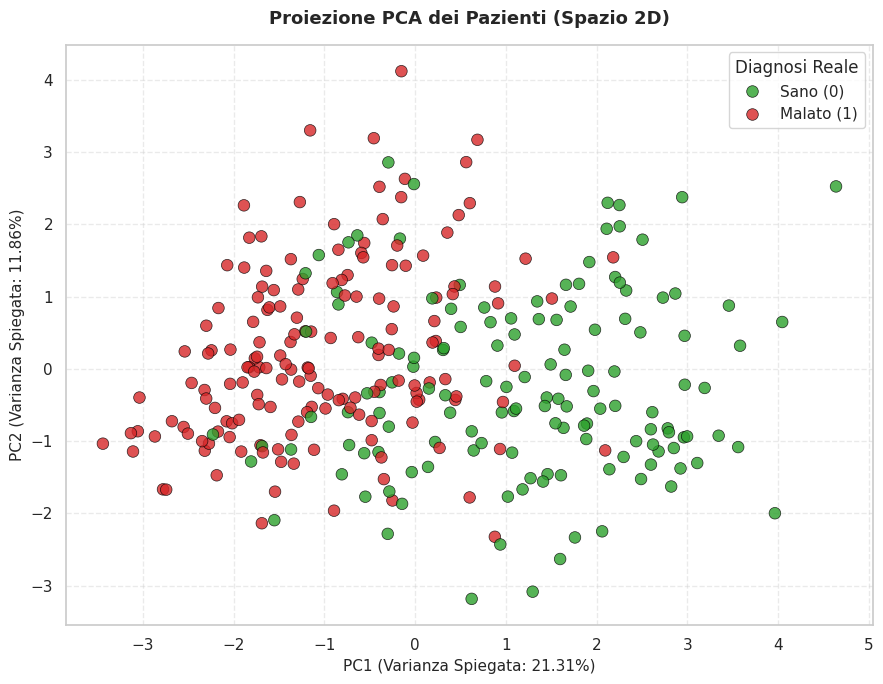

In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 6: 2D PATIENT SPACE PROJECTION
# =======================================================================

# --- 6.1 LOCAL STRUCTURE REPOSITORY INITIALIZATION ---
# Transforming PCA array into a structured DataFrame for clean Seaborn rendering
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Status'] = y.map({0: 'Sano (0)', 1: 'Malato (1)'})

# Dynamically fetching variance metrics to guarantee system consistency
var_exp = pca.explained_variance_ratio_ * 100

# --- 6.2 CANVAS PRESET & SCATTER DESIGN ---
plt.figure(figsize=(9, 7))

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Status',
    data=df_pca,
    palette=['#2ca02c', '#d62728'],  # Standardized clinical colors: Green for Healthy, Red for Diseased
    alpha=0.8,
    s=70,
    edgecolor='black',
    linewidth=0.5
)

# --- 6.3 TITLES AND AXIS FORMATTING ---
plt.title("Proiezione PCA dei Pazienti (Spazio 2D)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel(f"PC1 (Varianza Spiegata: {var_exp[0]:.2f}%)", fontsize=11, fontweight='medium')
plt.ylabel(f"PC2 (Varianza Spiegata: {var_exp[1]:.2f}%)", fontsize=11, fontweight='medium')

# --- 6.4 LAYOUT POLISHING ---
plt.legend(title="Diagnosi Reale", loc="upper right", frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 🔢 Data-Driven Selection of the Number of Clusters

Before fixing the number of K-Means clusters, we compare candidate solutions from \(K=2\) to \(K=8\). The Elbow Method evaluates the reduction in within-cluster inertia as additional clusters are introduced, whereas the Silhouette Score measures cohesion within clusters and separation between them. Considering both criteria reduces the risk of selecting \(K\) arbitrarily and provides quantitative support for the final clustering configuration.


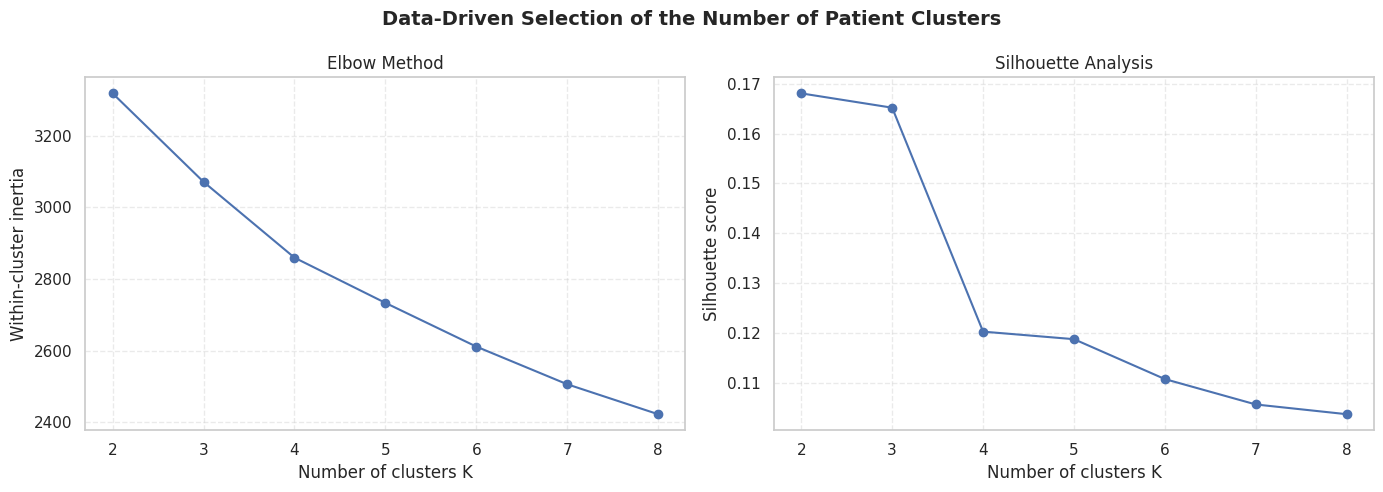

,K,Inertia,Silhouette
0,2,3317.8245,0.1681
1,3,3071.0041,0.1652
2,4,2859.6267,0.1203
3,5,2733.5818,0.1188
4,6,2611.6631,0.1107
5,7,2506.5822,0.1057
6,8,2423.0589,0.1037


In [ ]:
# =======================================================================
# PHASE 6.1: OPTIMAL NUMBER OF CLUSTERS
# =======================================================================

from sklearn.metrics import silhouette_score

k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters K')
axes[0].set_ylabel('Within-cluster inertia')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(k_values, silhouette_scores, marker='o')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xlabel('Number of clusters K')
axes[1].set_ylabel('Silhouette score')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle(
    'Data-Driven Selection of the Number of Patient Clusters',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

cluster_selection = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertias,
    'Silhouette': silhouette_scores
})

display(cluster_selection.round(4))

# Phase 7: Unsupervised Partitioning & Latent Space Boundary Auditing (K-Means Evaluation)

### 🎯 Objective
In this section, we transition to unsupervised partitioning to evaluate whether the continuous and discrete features group patients logically without relying on clinical diagnosis classes. By training a $K$-Means algorithm ($K=2$) directly on the standardized isotropic matrix, we can draw a direct mathematical comparison against the true diagnostic status and measure cluster separation boundaries through silhouette scoring metrics.

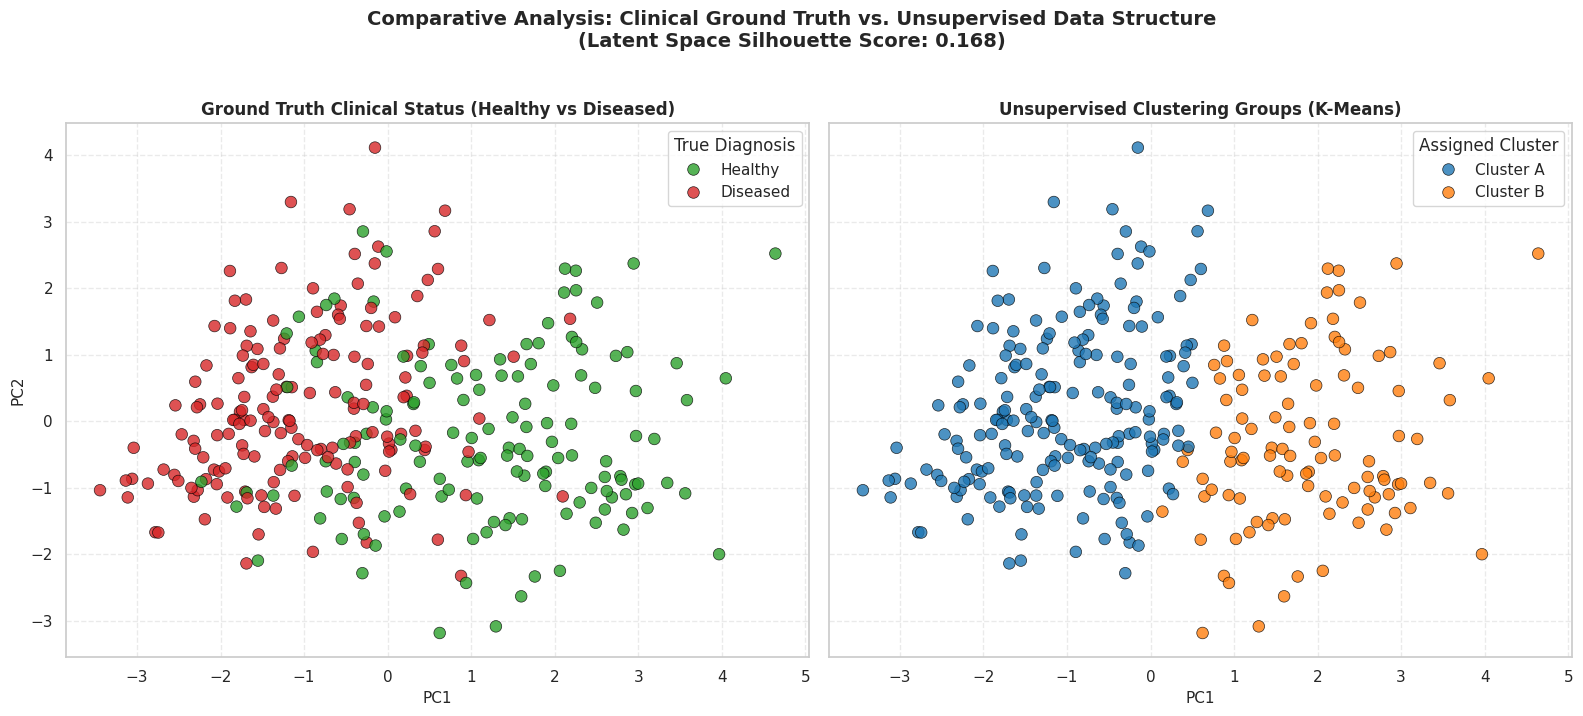


📊 CONTINGENCY AUDIT: GROUND TRUTH VS ASSIGNED CLUSTERS
Cluster      Cluster A  Cluster B
True_Status                      
Diseased           152         12
Healthy             44         94


In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 7: UNSUPERVISED K-MEANS CLUSTERING
# =======================================================================

# --- 7.1 EXECUTING CENTROID-BASED CLUSTERING ---
# Initializing K-Means setting K=2 to test the natural mathematical group split
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=2, n_init=15, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Calculating the global Silhouette Coefficient in the high-dimensional space
sil_score = silhouette_score(X_scaled, clusters)

# --- 7.2 LOCAL MAPPING DATASTRUCTURE PREPARATION ---
df_plot = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_plot['True_Status'] = y.map({0: 'Healthy', 1: 'Diseased'})
df_plot['Cluster'] = clusters
df_plot['Cluster'] = df_plot['Cluster'].map({0: 'Cluster A', 1: 'Cluster B'})

# --- 7.3 SPECULAR GRAPHICAL CANVAS DISPLAY ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Sub-Plot 1: Ground Truth Baseline
sns.scatterplot(
    x='PC1', y='PC2', hue='True_Status', data=df_plot,
    palette=['#2ca02c', '#d62728'], ax=axes[0], s=70, alpha=0.8, edgecolor='black', linewidth=0.5
)
axes[0].set_title("Ground Truth Clinical Status (Healthy vs Diseased)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("PC1", fontsize=11)
axes[0].set_ylabel("PC2", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].legend(title="True Diagnosis")

# Sub-Plot 2: Unsupervised Structural Clusters
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=df_plot,
    palette=['#1f77b4', '#ff7f0e'], ax=axes[1], s=70, alpha=0.8, edgecolor='black', linewidth=0.5
)
axes[1].set_title("Unsupervised Clustering Groups (K-Means)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("PC1", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].legend(title="Assigned Cluster")

# Final titles and layout adjustments
plt.suptitle(f"Comparative Analysis: Clinical Ground Truth vs. Unsupervised Data Structure\n(Latent Space Silhouette Score: {sil_score:.3f})",
             fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 7.4 CROSS-TABULATION CONTINGENCY PROFILE ---
print("\n" + "="*60)
print("📊 CONTINGENCY AUDIT: GROUND TRUTH VS ASSIGNED CLUSTERS")
print("="*60)
print(pd.crosstab(df_plot['True_Status'], df_plot['Cluster']))
print("="*60)

### ✅ Agreement Between Unsupervised Clusters and Clinical Diagnosis

Because K-Means is trained without access to the target label, its cluster identifiers cannot be compared directly through simple label matching. We therefore use the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI), two label-invariant metrics that quantify the structural agreement between the discovered partition and the true diagnostic classes. Higher values indicate that the unsupervised organization captures clinically meaningful information.


In [ ]:
# =======================================================================
# PHASE 7.1: CLUSTER-TO-TARGET AGREEMENT
# =======================================================================

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

print("=" * 60)
print("CLUSTER AGREEMENT WITH CLINICAL DIAGNOSIS")
print("=" * 60)
print(f"Adjusted Rand Index:          {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")
print("=" * 60)

CLUSTER AGREEMENT WITH CLINICAL DIAGNOSIS
Adjusted Rand Index:          0.394
Normalized Mutual Information: 0.329


### 🌳 Hierarchical Clustering and Dendrogram Validation

To verify whether the cluster structure is specific to K-Means or also emerges under a different unsupervised method, we apply agglomerative hierarchical clustering with Ward linkage. The dendrogram represents the progressive merging of patient groups according to their multivariate similarity. A horizontal cut corresponding to two clusters allows a visual assessment of the separation level and provides an independent validation of the \(K=2\) solution.


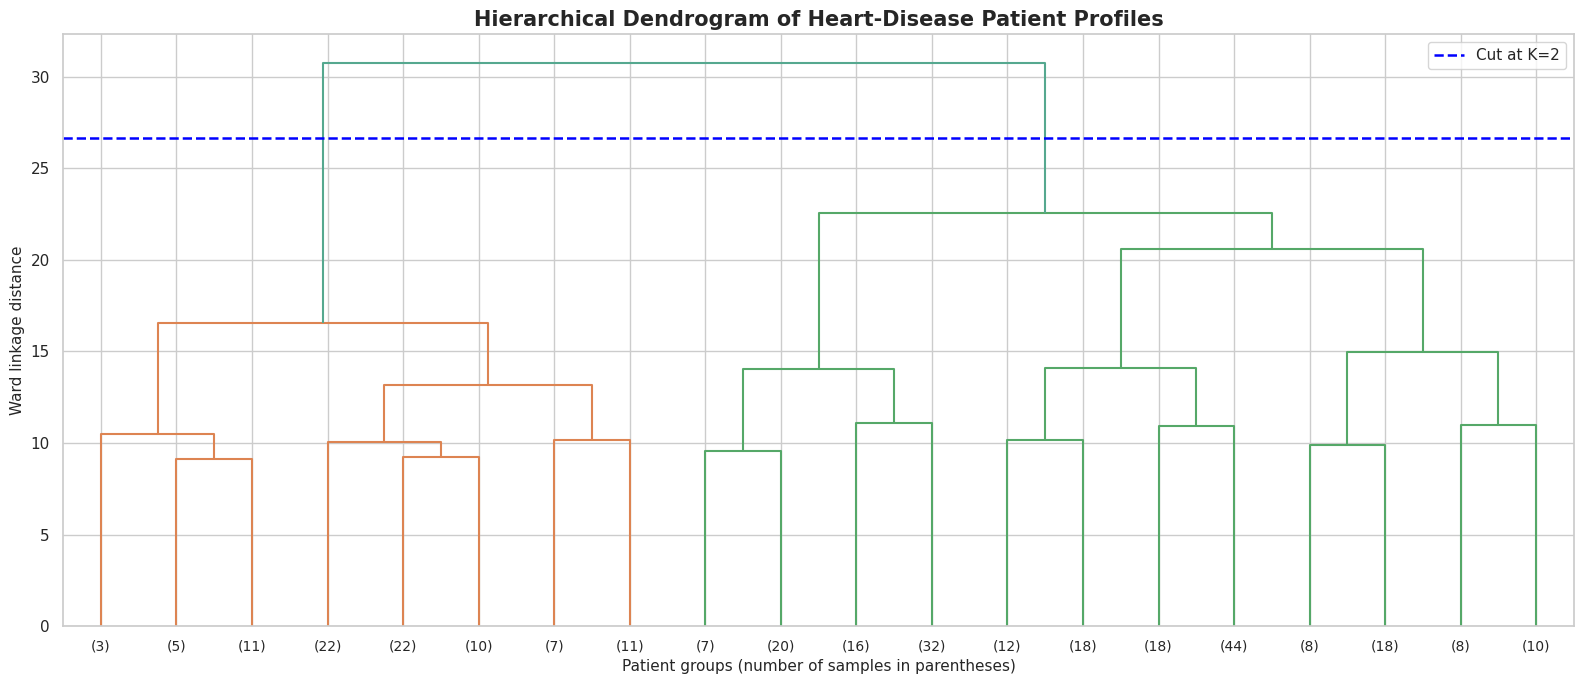

In [ ]:
# Phase 7.2: Hierarchical Clustering & Dendrogram Validation
# Ward hierarchical clustering on standardized patient profiles
Z = linkage(X_scaled, method='ward')

# For K=2, place the cut between the last two merge heights
cut_height = (Z[-2, 2] + Z[-1, 2]) / 2

plt.figure(figsize=(16, 7))
dendrogram(
    Z,
    truncate_mode='lastp',   # compact and readable representation
    p=20,
    show_leaf_counts=True,
    leaf_rotation=0,
    leaf_font_size=10,
    color_threshold=cut_height,
    above_threshold_color='#55a88f'
)

plt.axhline(
    cut_height,
    color='blue',
    linestyle='--',
    linewidth=1.8,
    label='Cut at K=2'
)

plt.title('Hierarchical Dendrogram of Heart-Disease Patient Profiles',
          fontsize=15, fontweight='bold')
plt.xlabel('Patient groups (number of samples in parentheses)', fontsize=11)
plt.ylabel('Ward linkage distance', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


### 🧬 Feature Drivers of the Unsupervised Clusters

After defining the clusters, we investigate which original clinical variables most strongly distinguish them. A Random Forest classifier is trained to predict the unsupervised cluster labels, and its feature-importance scores provide a global ranking of the variables associated with the partition. The most influential features are then standardized and compared across clusters, making their relative distributional differences directly interpretable.


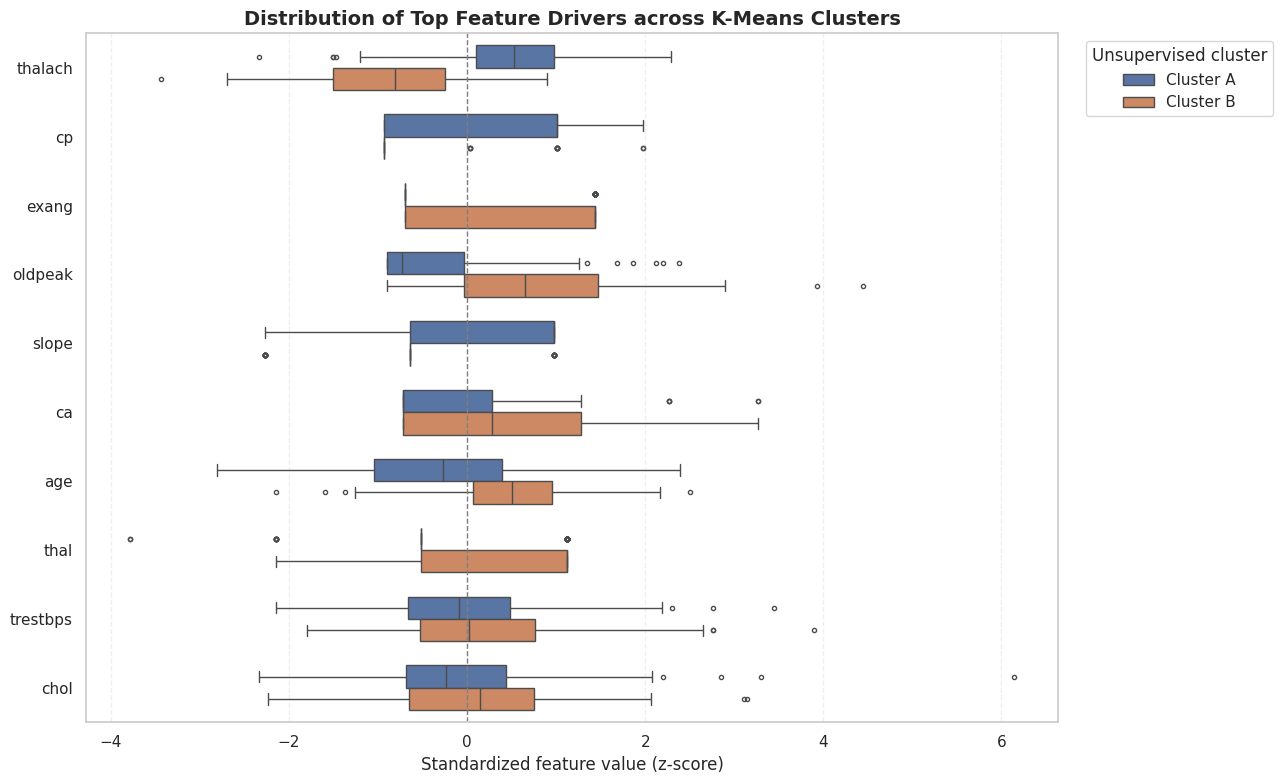

,Feature,Importance
0,thalach,0.2360
1,cp,0.1442
2,exang,0.1376
3,oldpeak,0.1080
4,slope,0.0956
5,ca,0.0747
6,age,0.0694
7,thal,0.0397
8,trestbps,0.0382
9,chol,0.0335


In [ ]:
# =======================================================================
# PHASE 7.3: FEATURE DRIVERS OF UNSUPERVISED CLUSTERS
# =======================================================================

if 'clusters' not in globals():
    raise RuntimeError(
        "La variabile 'clusters' non esiste. "
        "Esegui prima la Phase 8 con K-Means."
    )

rf_cluster = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Use the same original feature space employed to generate X_scaled
rf_cluster.fit(X, clusters)

driver_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_cluster.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

top_n = 10
top_features = driver_importance.head(top_n)['Feature'].tolist()

# Standardize the selected features only for graphical comparison
X_top_z = pd.DataFrame(
    StandardScaler().fit_transform(X[top_features]),
    columns=top_features,
    index=X.index
)

plot_data = X_top_z.copy()

plot_data['Cluster'] = pd.Series(
    clusters,
    index=X.index
).map({
    0: 'Cluster A',
    1: 'Cluster B'
})

plot_long = plot_data.melt(
    id_vars='Cluster',
    var_name='Feature',
    value_name='Standardized value'
)

plt.figure(figsize=(13, 8))

sns.boxplot(
    data=plot_long,
    x='Standardized value',
    y='Feature',
    hue='Cluster',
    order=top_features,
    width=0.65,
    fliersize=3
)

plt.axvline(
    0,
    color='gray',
    linestyle='--',
    linewidth=1
)

plt.title(
    'Distribution of Top Feature Drivers across K-Means Clusters',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Standardized feature value (z-score)')
plt.ylabel('')

plt.legend(
    title='Unsupervised cluster',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(
    True,
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

display(
    driver_importance
    .head(10)
    .reset_index(drop=True)
    .round(4)
)

# Phase 8: Advanced Patient Distribution & Biomarker Stratification

### 🎯 Objective
To supplement our unsupervised clustering partition, we perform a deep statistical stratification of the core continuous patient biomarkers (`age`, `thalach`, `oldpeak`). By mapping the exact density distribution variations directly across the positive and negative disease cohorts, we can visually capture how specific continuous clinical metrics split and differentiate healthy individuals from those at high cardiovascular risk.

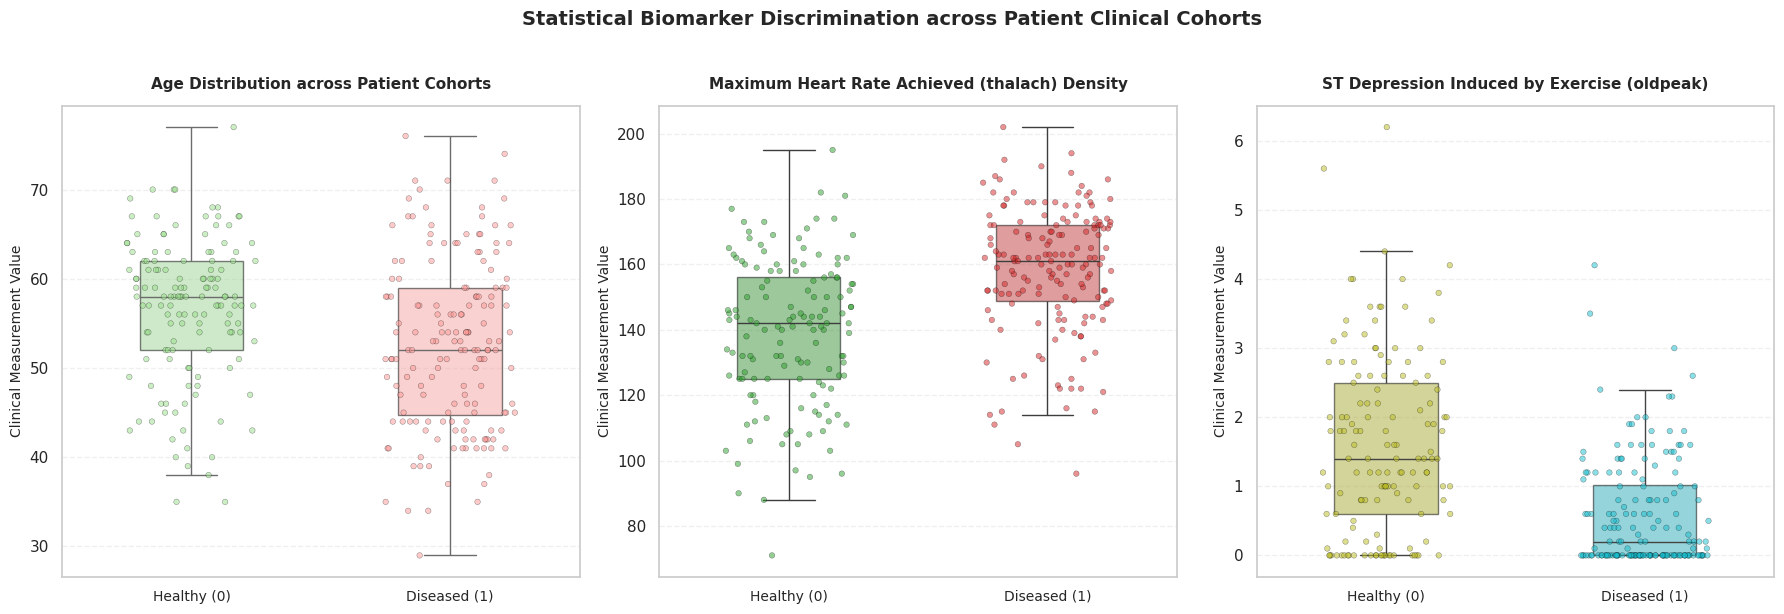

In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 8: BIOMARKER DRIVER STRATIFICATION
# =======================================================================

# --- 8.1 DEFINING TARGET METRICS & COSMETIC PARAMETERS ---
drivers = ['age', 'thalach', 'oldpeak']
titles = [
    'Age Distribution across Patient Cohorts',
    'Maximum Heart Rate Achieved (thalach) Density',
    'ST Depression Induced by Exercise (oldpeak)'
]
# Unified, clean scientific color themes
palettes = [['#98df8a', '#ff9896'], ['#2ca02c', '#d62728'], ['#bcbd22', '#17becf']]

# --- 8.2 CANVAS GRID INITIALIZATION ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 8.3 ITERATIVE MULTI-VEW COHORT MAPPING ---
for i, var in enumerate(drivers):
    # Combining a transparent boxplot with jittered data point density (Stripplot)
    sns.boxplot(
        x='target', y=var, data=df, ax=axes[i],
        palette=palettes[i], width=0.4, fliersize=0, boxprops=dict(alpha=0.5, edgecolor='black', lw=1)
    )
    sns.stripplot(
        x='target', y=var, data=df, ax=axes[i],
        palette=palettes[i], size=4, jitter=0.25, alpha=0.5, edgecolor='black', linewidth=0.3
    )

    # Polishing sub-plot typography and grids
    axes[i].set_title(titles[i], fontsize=11, fontweight='bold', pad=12)
    axes[i].set_xticklabels(['Healthy (0)', 'Diseased (1)'], fontsize=10)
    axes[i].set_xlabel('', fontsize=10)
    axes[i].set_ylabel('Clinical Measurement Value', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.3, axis='y')

# --- 8.4 GLOBAL ARCHITECTURAL FINISHING ---
plt.suptitle("Statistical Biomarker Discrimination across Patient Clinical Cohorts", fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# Phase 9: Multi-Source Data Fusion (Integrating Clinical and Diagnostic Profiles)

### 🎯 Objective
In real-world biomedical studies, researchers often combine different data modalities (like genomics and clinical notes) to get a complete view of a patient's health. To replicate this multi-omics data fusion framework, we split our feature space into two distinct physiological blocks: a "Clinical & Demographics" profile and a "Diagnostic & Stress Test" profile. We scale each view independently, run separate PCA decompositions, and merge their first principal components to analyze how these two domains interact.

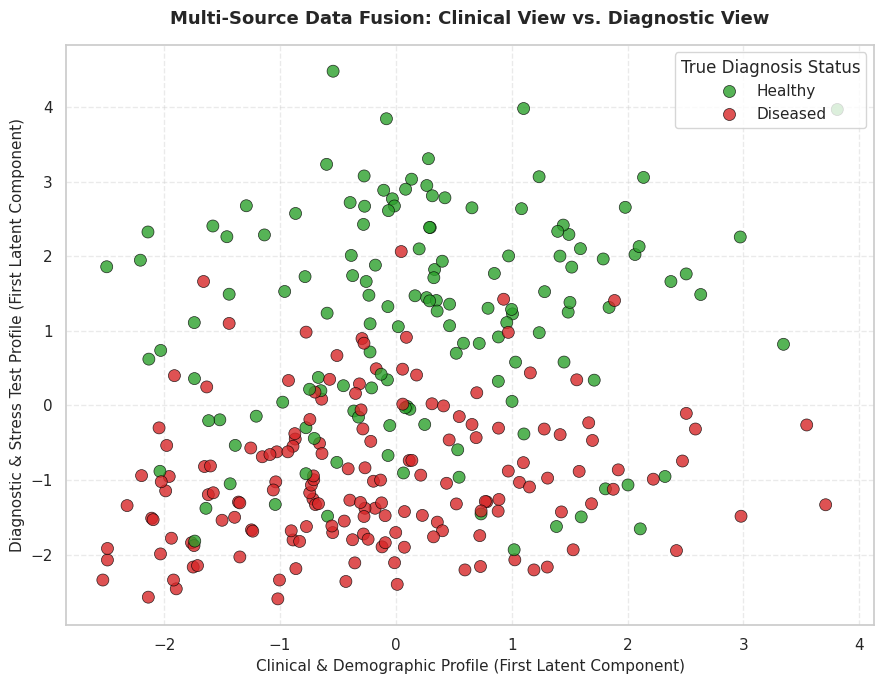

In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 9: MULTI-SOURCE LATE DATA FUSION
# =======================================================================

# --- 9.1 MULTI-MODAL FEATURING SPLITTING ---
# Modality 1: Clinical baseline and demographic variables
clinical_features = ['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg']
X_clinical = df[clinical_features]

# Modality 2: Diagnostic performance and stress test measurements
diagnostic_features = ['thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'cp']
X_diagnostic = df[diagnostic_features]

# --- 9.2 INDEPENDENT COMPONENT STANDARD SCALING ---
# Scaling both data modalities independently to normalize variation across medical blocks
scaler_c = StandardScaler()
scaler_d = StandardScaler()

X_clinical_scaled = scaler_c.fit_transform(X_clinical)
X_diagnostic_scaled = scaler_d.fit_transform(X_diagnostic)

# --- 9.3 INDEPENDENT LATENT SPACE DECOMPOSITION (PCA) ---
pca_clinical = PCA(n_components=2, random_state=42)
pca_diagnostic = PCA(n_components=2, random_state=42)

X_clinical_pca = pca_clinical.fit_transform(X_clinical_scaled)
X_diagnostic_pca = pca_diagnostic.fit_transform(X_diagnostic_scaled)

# --- 9.4 LATE DATA FUSION MATRIX GENERATION ---
# Merging the primary latent vectors from each block into a unified joint dataframe
df_fusion = pd.DataFrame({
    'Clinical_PC1': X_clinical_pca[:, 0],
    'Diagnostic_PC1': X_diagnostic_pca[:, 0],
    'Status': y.map({0: 'Healthy', 1: 'Diseased'})
})

# --- 9.5 FUSION CANVAS DESIGN & MAPPING ---
plt.figure(figsize=(9, 7))

sns.scatterplot(
    x='Clinical_PC1', y='Diagnostic_PC1', hue='Status', data=df_fusion,
    palette=['#2ca02c', '#d62728'], s=75, alpha=0.8, edgecolor='black', linewidth=0.5
)

# Polishing titles and axis descriptions
plt.title("Multi-Source Data Fusion: Clinical View vs. Diagnostic View", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Clinical & Demographic Profile (First Latent Component)", fontsize=11, fontweight='medium')
plt.ylabel("Diagnostic & Stress Test Profile (First Latent Component)", fontsize=11, fontweight='medium')

# Formatting layout properties
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title="True Diagnosis Status", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

### 🔗 Patient Similarity Across Clinical and Diagnostic Views

The previous fusion analysis summarizes each data source through principal components. Here, we complement that representation by examining patient-to-patient similarity separately within the clinical and diagnostic feature blocks. Euclidean distance matrices are computed after standardization and reordered through hierarchical clustering, producing heatmaps that reveal groups of patients with comparable profiles and indicate whether the two data modalities generate consistent or distinct similarity structures.


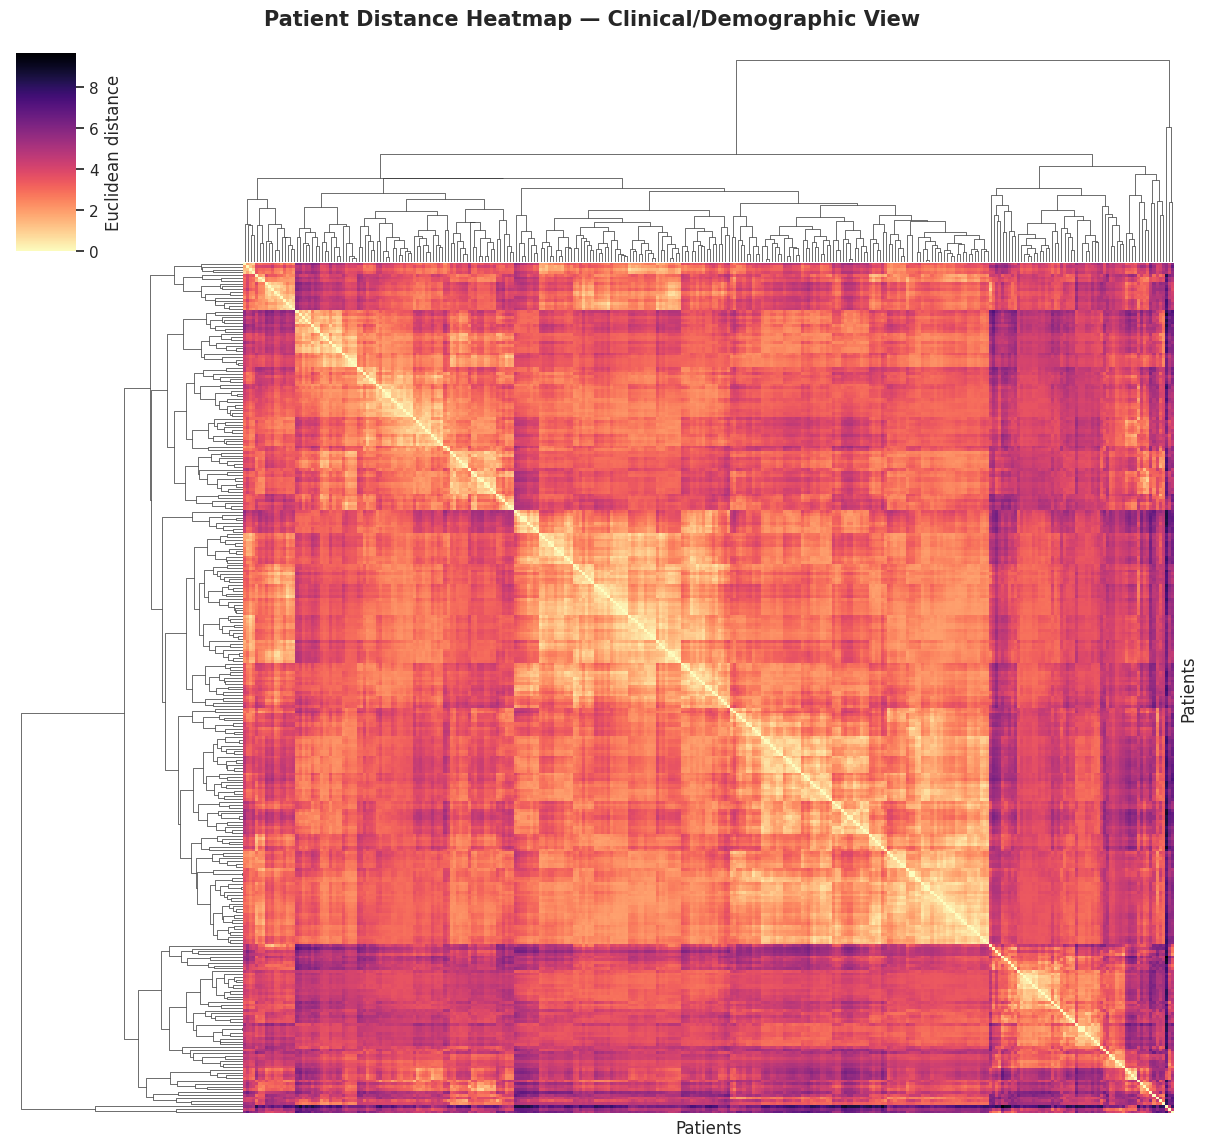

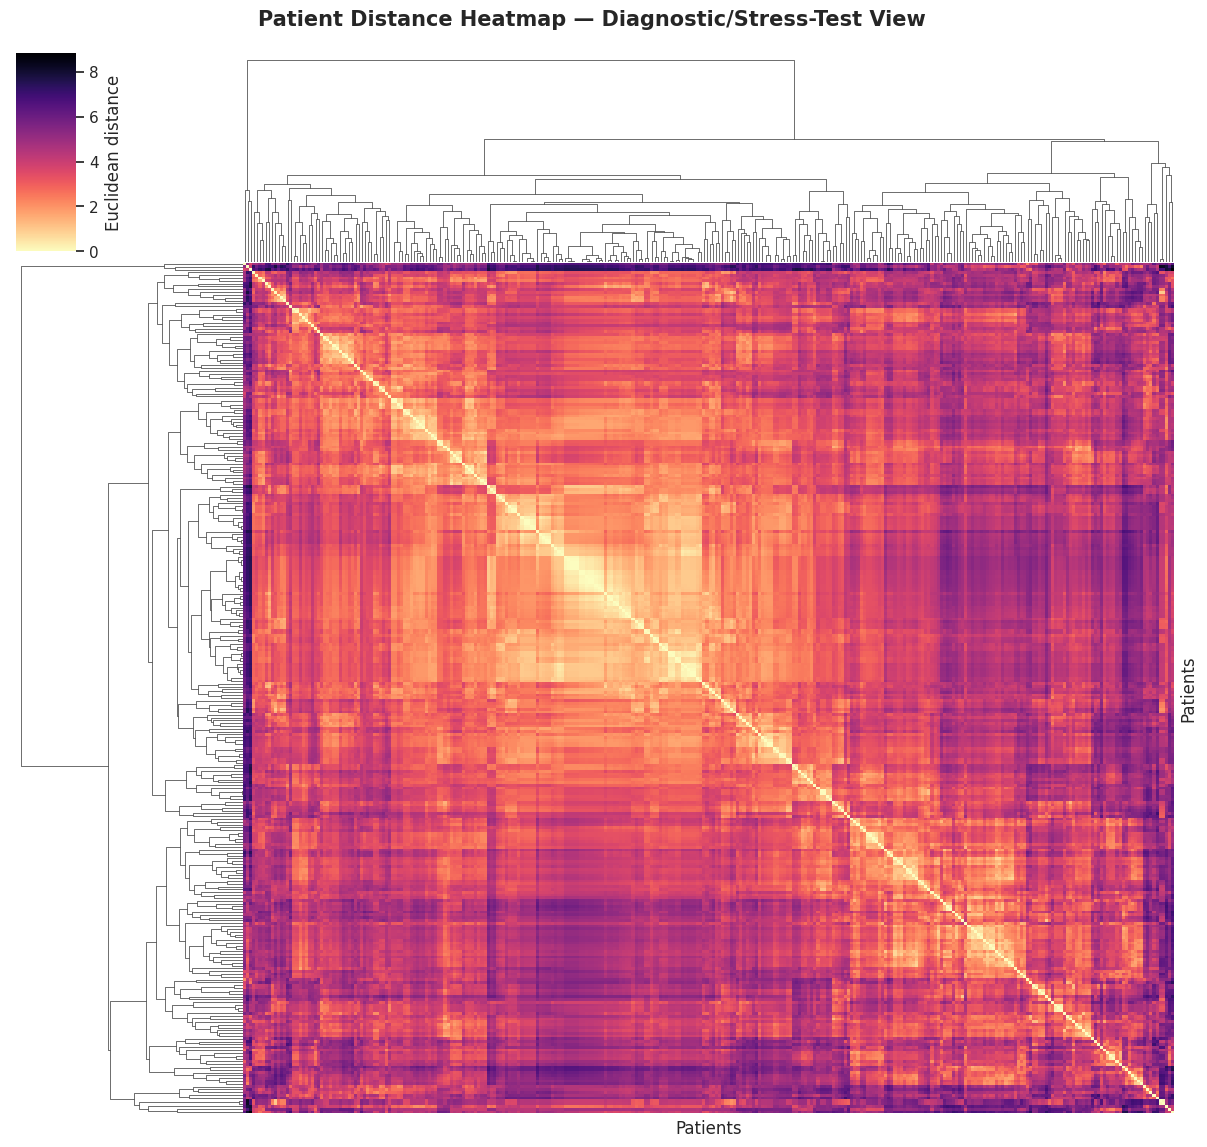

In [ ]:
# Phase 9.1: Patient Similarity within Clinical and Diagnostic Views
clinical_features = ['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg']
diagnostic_features = ['thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'cp']

def patient_distance_clustermap(dataframe, title):
    # Standardize each feature before measuring patient-to-patient distance
    scaled = StandardScaler().fit_transform(dataframe)

    # Correlation distance: 0 = very similar profile, 2 = opposite profile
    distance = pairwise_distances(scaled, metric='euclidean')
    distance = np.nan_to_num(distance, nan=0.0, posinf=2.0, neginf=0.0)

    distance_df = pd.DataFrame(
        distance,
        index=dataframe.index,
        columns=dataframe.index
    )

    grid = sns.clustermap(
        distance_df,
        method='average',
        metric='euclidean',
        cmap='magma_r',
        figsize=(12, 11),
        xticklabels=False,
        yticklabels=False,
        cbar_kws={'label': 'Euclidean distance'}
    )
    grid.fig.suptitle(title, fontsize=15, fontweight='bold', y=1.02)
    grid.ax_heatmap.set_xlabel('Patients')
    grid.ax_heatmap.set_ylabel('Patients')
    plt.show()

patient_distance_clustermap(
    df[clinical_features],
    'Patient Distance Heatmap — Clinical/Demographic View'
)

patient_distance_clustermap(
    df[diagnostic_features],
    'Patient Distance Heatmap — Diagnostic/Stress-Test View'
)

# Phase 10: Global Model Explainability & Computational Pathology Drivers

### 🎯 Objective
To conclude our multi-omic and scientific visualization pipeline, we implement an interpretable machine learning layer to extract absolute feature importance scores. By training an Ensemble Random Forest Classifier directly on the standardized dataset, we shift from unsupervised geometric clusters to a supervised global explainability analysis. This allows us to computationally rank which clinical biomarkers hold the highest deterministic weight in driving the decision boundaries between health and cardiac disease.

### 🧪 Predictive Validation of the Random Forest Model

Before interpreting feature importance, we evaluate whether the Random Forest can generalize to unseen patients. The dataset is divided into stratified training and test subsets so that the class distribution is preserved. Performance is assessed through accuracy, ROC-AUC, the classification report, the confusion matrix, and the ROC curve, providing complementary evidence on discrimination quality and class-specific prediction errors.


RANDOM FOREST TEST-SET PERFORMANCE
Accuracy: 0.803
ROC-AUC:  0.868
              precision    recall  f1-score   support

     Healthy       0.79      0.77      0.78        35
    Diseased       0.81      0.83      0.82        41

    accuracy                           0.80        76
   macro avg       0.80      0.80      0.80        76
weighted avg       0.80      0.80      0.80        76



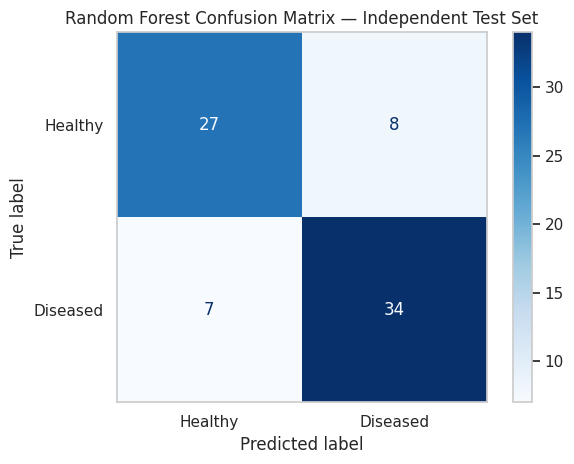

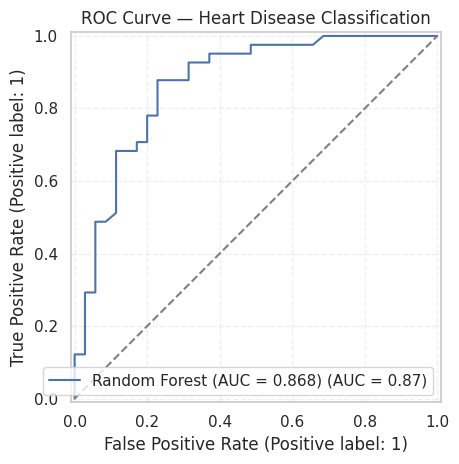

In [ ]:
# =======================================================================
# PHASE 10: RANDOM FOREST PREDICTIVE VALIDATION
# =======================================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

rf_validation = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_validation.fit(X_train, y_train)

y_pred = rf_validation.predict(X_test)
y_prob = rf_validation.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("=" * 65)
print("RANDOM FOREST TEST-SET PERFORMANCE")
print("=" * 65)
print(f"Accuracy: {accuracy:.3f}")
print(f"ROC-AUC:  {auc:.3f}")
print("=" * 65)
print(classification_report(
    y_test,
    y_pred,
    target_names=['Healthy', 'Diseased']
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Healthy', 'Diseased'],
    cmap='Blues',
    values_format='d'
)

plt.title('Random Forest Confusion Matrix — Independent Test Set')
plt.grid(False)
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name=f'Random Forest (AUC = {auc:.3f})'
)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve — Heart Disease Classification')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 🌐 Global Feature Importance

Once predictive performance has been assessed, the Random Forest is refitted on the complete standardized dataset to obtain a global ranking of clinical variables. Feature importance is calculated from the average reduction in node impurity produced by each variable across the ensemble of decision trees. The horizontal bar chart highlights the biomarkers that contribute most strongly to the model’s overall classification decisions.


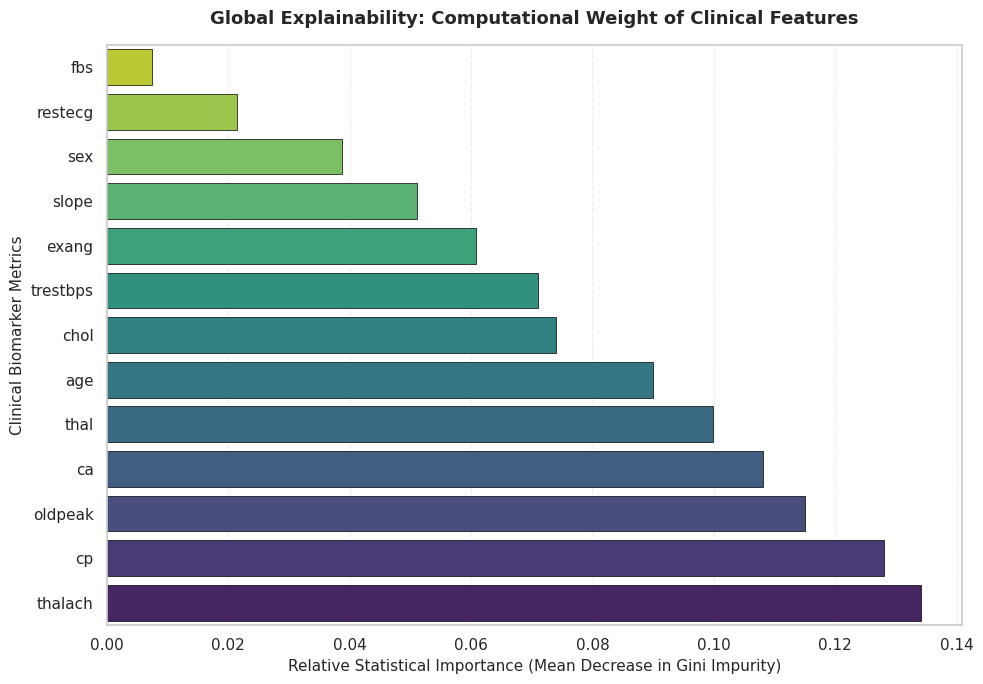

In [ ]:
# =======================================================================
#    HEART DISEASE PROJECT - PHASE 10.1: GLOBAL FEATURE IMPORTANCE
# =======================================================================
from sklearn.ensemble import RandomForestClassifier

# --- 10.1 TRAINING THE ENSEMBLE EXPLAINER ---
# Initializing an ensemble Random Forest model to compute Gini impurity rankings
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_scaled, y)

# --- 10.2 EXTRACTING METRIC WEIGHT RANKINGS ---
# Structuring the model importances into an ordered DataFrame for plotting
importances = rf_model.feature_importances_
feature_names = X.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# --- 10.3 PLOTTING THE RANKING CANVASSING ---
plt.figure(figsize=(10, 7))

# Mapping horizontal bars using a reversed professional colormap (viridis_r)
sns.barplot(
    x='Importance',
    y='Feature',
    data=df_importance,
    palette='viridis_r',
    edgecolor='black',
    linewidth=0.5
)

# Refining titles and axis semantics
plt.title("Global Explainability: Computational Weight of Clinical Features", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Relative Statistical Importance (Mean Decrease in Gini Impurity)", fontsize=11, fontweight='medium')
plt.ylabel("Clinical Biomarker Metrics", fontsize=11, fontweight='medium')

# Setting up a polished layout matrix
plt.grid(True, linestyle='--', alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 📐 Statistical Effect Size and Odds-Ratio Analysis

Machine-learning importance scores indicate predictive relevance but do not directly express the direction or magnitude of association with disease. To complement the Random Forest analysis, we fit a multivariable logistic regression model after encoding categorical predictors and standardizing all inputs. Odds ratios and 95% confidence intervals are displayed in a forest plot: values above 1 indicate increased odds of heart disease, values below 1 indicate reduced odds, and intervals crossing 1 suggest statistical uncertainty in the estimated association.


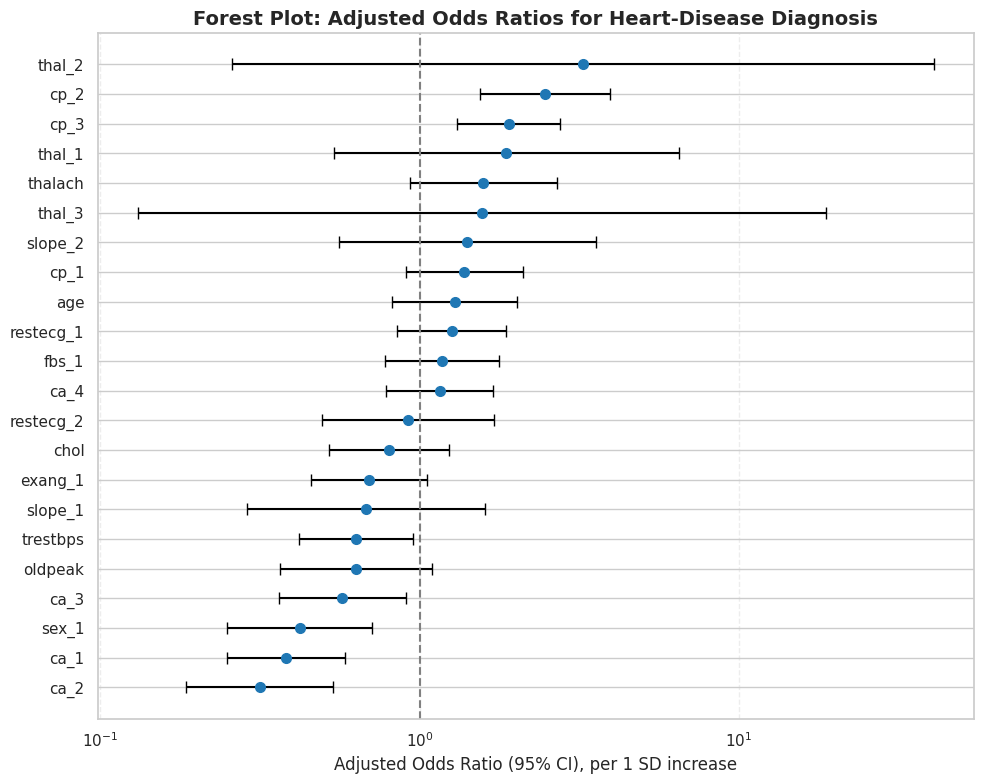

,Feature,OR,CI_low,CI_high
0,ca_2,0.315,0.186,0.534
1,ca_1,0.382,0.250,0.584
2,sex_1,0.420,0.250,0.707
3,ca_3,0.572,0.362,0.903
4,oldpeak,0.631,0.364,1.094
5,trestbps,0.632,0.419,0.953
6,slope_1,0.680,0.287,1.607
7,exang_1,0.694,0.458,1.051
8,chol,0.801,0.521,1.232
9,restecg_2,0.922,0.496,1.714


In [ ]:
# Phase 10.2: Statistical Effect Size & Odds Ratio Analysis
categorical_cols_or = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]

X_or_raw = pd.get_dummies(
    X,
    columns=categorical_cols_or,
    drop_first=True,
    dtype=float
)

X_or = pd.DataFrame(
    StandardScaler().fit_transform(X_or_raw),
    columns=X_or_raw.columns,
    index=X_or_raw.index
)

X_or = sm.add_constant(X_or)
logit_model = sm.Logit(y, X_or).fit(disp=False, maxiter=1000)

params = logit_model.params.drop('const')
conf = logit_model.conf_int().drop(index='const')

forest_df = pd.DataFrame({
    'Feature': params.index,
    'OR': np.exp(params.values),
    'CI_low': np.exp(conf[0].values),
    'CI_high': np.exp(conf[1].values)
})

# Sort by effect size for a cleaner plot
forest_df = forest_df.sort_values('OR').reset_index(drop=True)
y_pos = np.arange(len(forest_df))

fig, ax = plt.subplots(figsize=(10, 8))

xerr = np.vstack([
    forest_df['OR'] - forest_df['CI_low'],
    forest_df['CI_high'] - forest_df['OR']
])

ax.errorbar(
    forest_df['OR'],
    y_pos,
    xerr=xerr,
    fmt='o',
    color='#1f77b4',
    ecolor='black',
    capsize=4,
    markersize=7,
    linewidth=1.5
)

ax.axvline(1, color='gray', linestyle='--', linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df['Feature'])
ax.set_xscale('log')
ax.set_xlabel('Adjusted Odds Ratio (95% CI), per 1 SD increase')
ax.set_ylabel('')
ax.set_title('Forest Plot: Adjusted Odds Ratios for Heart-Disease Diagnosis',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

display(forest_df.round(3))
